# Task 2: Initial Stock Price Technical Analysis

## Project Context

This notebook performs initial quantitative analysis on historical stock price data. The objective is to prepare stock market datasets, compute technical indicators, and identify early price and momentum patterns that may later be connected with financial news sentiment.

The analysis supports Nova Financial Solutions’ goal of improving predictive analytics through integrated market and news intelligence.

In [1]:
import os
import sys
import warnings

project_root = os.path.abspath("..")
sys.path.append(project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import talib

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## 1. Data Loading

The historical stock price dataset contains daily trading information including open price, high price, low price, closing price, adjusted close price, and trading volume.

Missing values were inspected during data loading. The dataset contained minimal missing observations, and rolling-window calculations naturally introduced NaN values at the beginning of indicator series. These were retained where appropriate to preserve calculation integrity.

In [2]:
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
aapl_path = project_root / "data" / "raw" / "AAPL.csv"

print(f"Loading file from: {aapl_path}")

aapl_df = pd.read_csv(aapl_path)

aapl_df.head()

Loading file from: /Users/mariya/Documents/10 Academy/news-sentiment-analysis/data/raw/AAPL.csv


,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
aapl_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   object 
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 177.0+ KB


In [4]:
aapl_df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

### Data Quality Observation

The stock price dataset was checked for missing values and data type consistency before technical indicators were computed. Proper date formatting and numeric conversion are essential for reliable quantitative analysis.

In [5]:
aapl_df["Date"] = pd.to_datetime(aapl_df["Date"])

aapl_df = aapl_df.sort_values("Date")

aapl_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


## 2. Closing Price Trend Analysis

Closing price trends provide an overview of long-term market direction and price behavior over time.

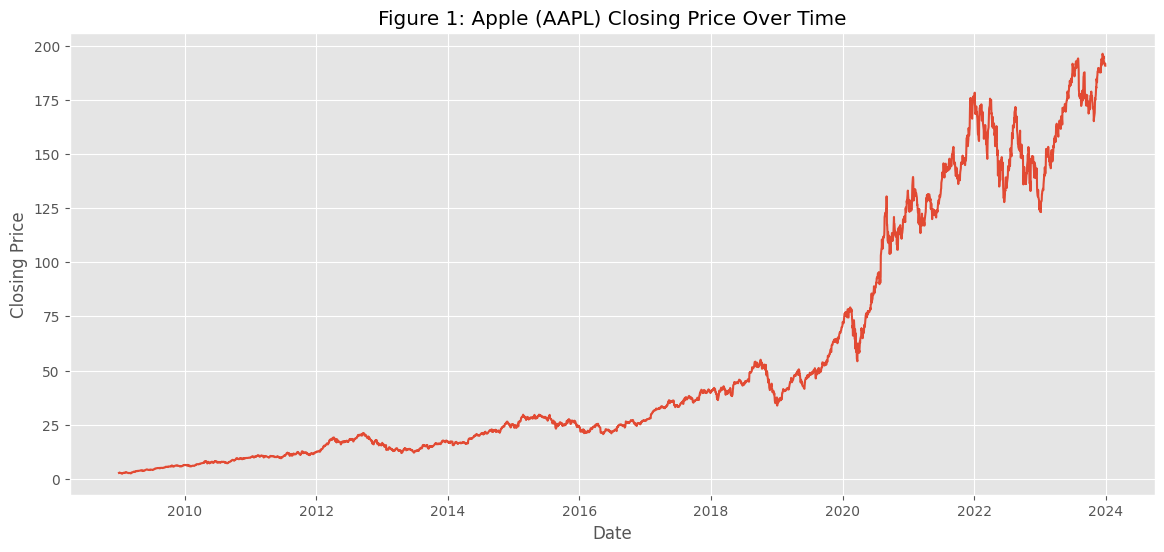

In [6]:
plt.figure(figsize=(14,6))

plt.plot(aapl_df["Date"], aapl_df["Close"])

plt.title("Figure 1: Apple (AAPL) Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

### Interpretation of Figure 1

Figure 1 shows the long-term movement of Apple’s stock price across the study period. The overall trend reflects periods of growth, correction, and recovery that may later be compared against periods of strong positive or negative news sentiment.

## Technical Indicators with TA-Lib

The following technical indicators were computed using TA-Lib to align with the challenge requirements and ensure standardized financial indicator calculations.

## 3. Simple Moving Average (SMA)

The Simple Moving Average smooths short-term fluctuations and helps identify the underlying trend direction of a stock.

In [7]:
aapl_df["SMA_20"] = talib.SMA(aapl_df["Close"], timeperiod=20)
aapl_df["SMA_50"] = talib.SMA(aapl_df["Close"], timeperiod=50)

aapl_df[["Date", "Close", "SMA_20", "SMA_50"]].head()

,Date,Close,SMA_20,SMA_50
0,2009-01-02,2.721686,NaN,NaN
1,2009-01-05,2.836553,NaN,NaN
2,2009-01-06,2.789767,NaN,NaN
3,2009-01-07,2.729484,NaN,NaN
4,2009-01-08,2.780169,NaN,NaN


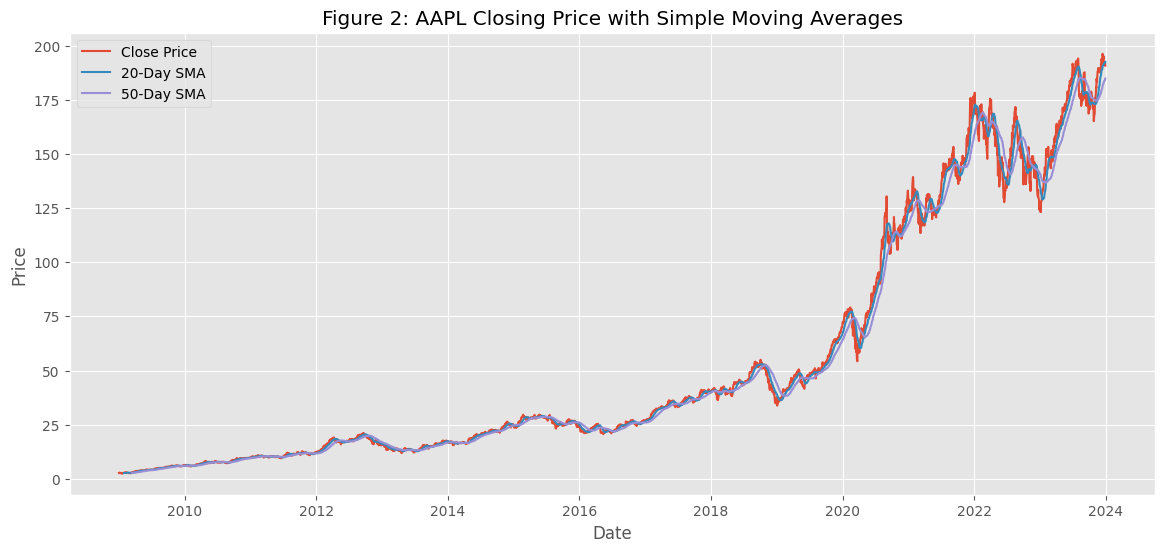

In [8]:
plt.figure(figsize=(14,6))

plt.plot(aapl_df["Date"], aapl_df["Close"], label="Close Price")

plt.plot(aapl_df["Date"], aapl_df["SMA_20"], label="20-Day SMA")

plt.plot(aapl_df["Date"], aapl_df["SMA_50"], label="50-Day SMA")

plt.title("Figure 2: AAPL Closing Price with Simple Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

### Interpretation of Figure 2

Figure 2 shows the relationship between Apple’s closing price and its short-term and medium-term moving averages. Moving averages smooth daily volatility and help identify trend direction. Crossovers between short-term and long-term averages may signal changes in market momentum.

## 4. Exponential Moving Average (EMA)

Unlike SMA, the Exponential Moving Average gives greater weight to recent prices, making it more responsive to recent market changes.

In [9]:
aapl_df["EMA_20"] = talib.EMA(aapl_df["Close"], timeperiod=20)
aapl_df["EMA_50"] = talib.EMA(aapl_df["Close"], timeperiod=50)

aapl_df[["Date", "Close", "EMA_20", "EMA_50"]].head()

,Date,Close,EMA_20,EMA_50
0,2009-01-02,2.721686,NaN,NaN
1,2009-01-05,2.836553,NaN,NaN
2,2009-01-06,2.789767,NaN,NaN
3,2009-01-07,2.729484,NaN,NaN
4,2009-01-08,2.780169,NaN,NaN


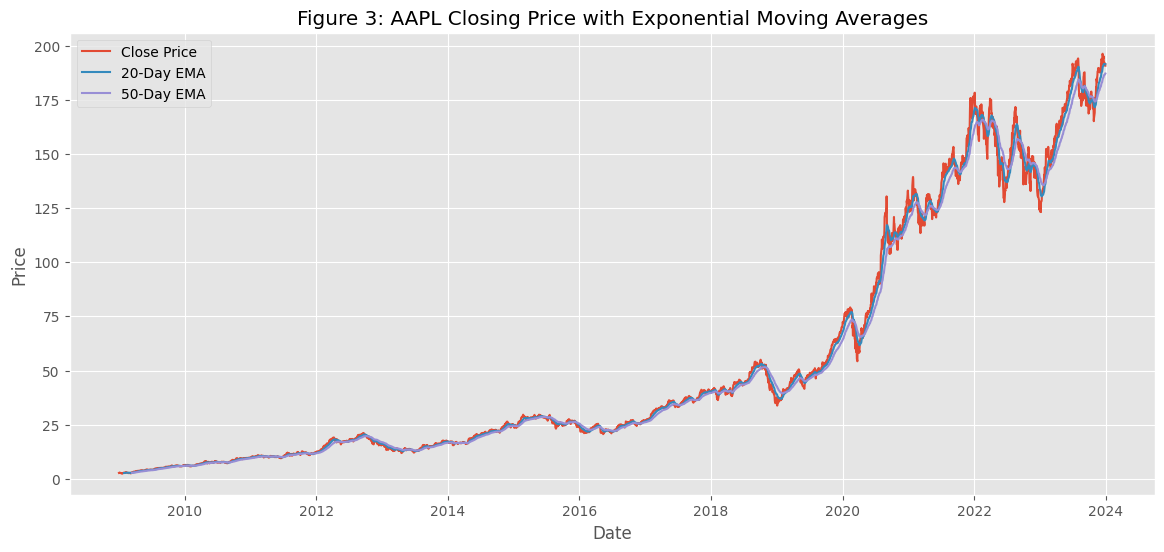

In [10]:
plt.figure(figsize=(14,6))

plt.plot(aapl_df["Date"], aapl_df["Close"], label="Close Price")

plt.plot(aapl_df["Date"], aapl_df["EMA_20"], label="20-Day EMA")

plt.plot(aapl_df["Date"], aapl_df["EMA_50"], label="50-Day EMA")

plt.title("Figure 3: AAPL Closing Price with Exponential Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

### Interpretation of Figure 3

Figure 3 shows that exponential moving averages react more quickly to recent price changes compared with simple moving averages. This makes EMA useful for detecting short-term market momentum and trend reversals.

## 5. Relative Strength Index (RSI)

The Relative Strength Index is a momentum indicator used to identify overbought and oversold conditions in the market.

In [11]:
aapl_df["RSI_14"] = talib.RSI(aapl_df["Close"], timeperiod=14)

aapl_df[["Date", "Close", "RSI_14"]].head()

,Date,Close,RSI_14
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,NaN
2,2009-01-06,2.789767,NaN
3,2009-01-07,2.729484,NaN
4,2009-01-08,2.780169,NaN


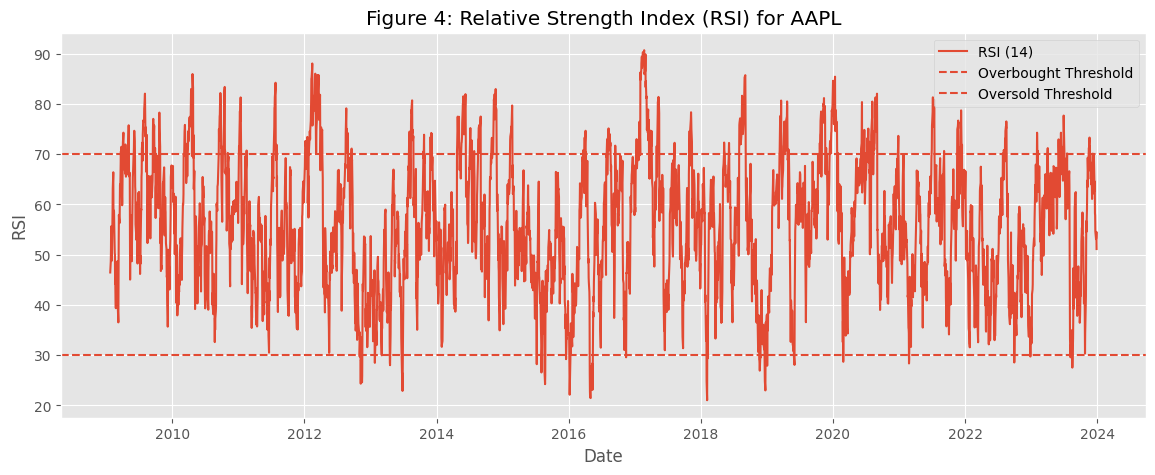

In [12]:
plt.figure(figsize=(14,5))

plt.plot(aapl_df["Date"], aapl_df["RSI_14"], label="RSI (14)")

plt.axhline(70, linestyle="--", label="Overbought Threshold")
plt.axhline(30, linestyle="--", label="Oversold Threshold")

plt.title("Figure 4: Relative Strength Index (RSI) for AAPL")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()

plt.show()

### Interpretation of Figure 4

Figure 4 shows momentum fluctuations in Apple’s stock price. RSI values above 70 may indicate overbought conditions, while values below 30 may suggest oversold conditions. These momentum shifts may later be compared with changes in financial news sentiment.

## Moving Average Convergence Divergence (MACD)

MACD is a momentum indicator used to detect trend direction, momentum strength, and possible reversal signals.

In [13]:
aapl_df["MACD"], aapl_df["MACD_signal"], aapl_df["MACD_hist"] = talib.MACD(
    aapl_df["Close"],
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

aapl_df[["Date", "MACD", "MACD_signal", "MACD_hist"]].head()

,Date,MACD,MACD_signal,MACD_hist
0,2009-01-02,NaN,NaN,NaN
1,2009-01-05,NaN,NaN,NaN
2,2009-01-06,NaN,NaN,NaN
3,2009-01-07,NaN,NaN,NaN
4,2009-01-08,NaN,NaN,NaN


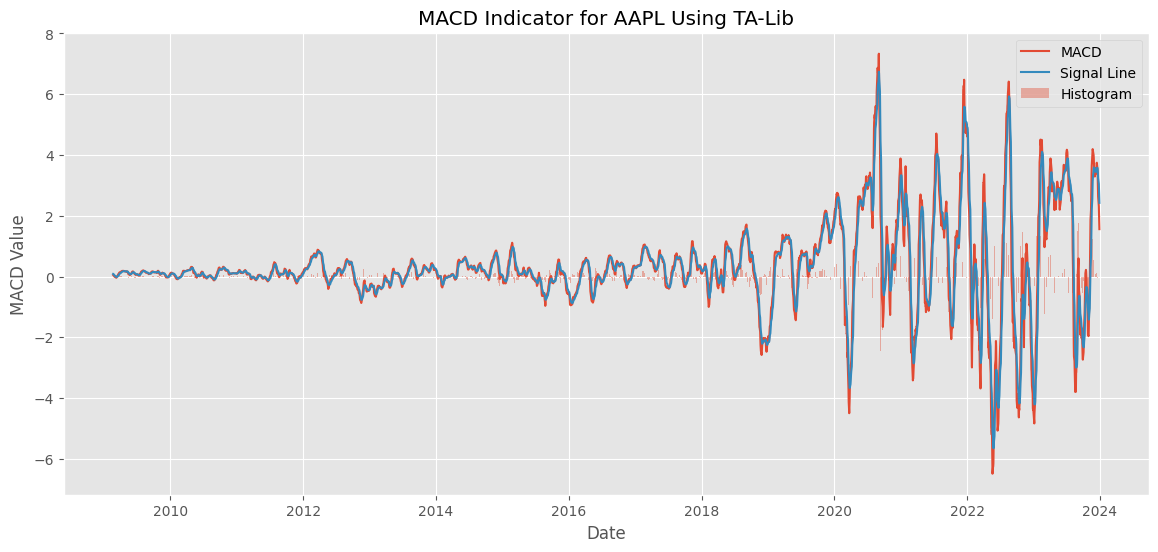

In [14]:
plt.figure(figsize=(14, 6))

plt.plot(aapl_df["Date"], aapl_df["MACD"], label="MACD")
plt.plot(aapl_df["Date"], aapl_df["MACD_signal"], label="Signal Line")
plt.bar(aapl_df["Date"], aapl_df["MACD_hist"], label="Histogram", alpha=0.4)

plt.title("MACD Indicator for AAPL Using TA-Lib")
plt.xlabel("Date")
plt.ylabel("MACD Value")
plt.legend()

plt.show()

### Interpretation

The MACD indicator highlights changes in market momentum and trend direction. Crossovers between the MACD line and signal line may indicate bullish or bearish momentum shifts. The histogram illustrates the strength of momentum changes over time.

## Trading and Risk-Management Interpretation

SMA and EMA provide trend-following signals by smoothing price movement, RSI identifies potential overbought or oversold conditions, and MACD confirms momentum shifts. Used together, these indicators can support a basic trading rule set: follow the broader SMA/EMA trend, avoid entries when RSI shows extreme conditions, and use MACD crossovers as confirmation before entering or exiting a position.

From a risk-management perspective, conflicting signals should be treated cautiously. For example, a bullish MACD signal during an overbought RSI period may suggest momentum strength but also elevated reversal risk.

## 6. Daily Return Analysis

Daily returns were calculated using the adjusted close price when available; otherwise, the closing price was used.

In [15]:
# Clean column names
aapl_df.columns = aapl_df.columns.str.strip()

# Select adjusted close if available, otherwise use close
if "Adj Close" in aapl_df.columns:
    price_col = "Adj Close"
elif "Adj_Close" in aapl_df.columns:
    price_col = "Adj_Close"
elif "adj_close" in aapl_df.columns:
    price_col = "adj_close"
else:
    price_col = "Close"

aapl_df["Daily_Return"] = aapl_df[price_col].pct_change() * 100

aapl_df[["Date", price_col, "Daily_Return"]].head()

,Date,Close,Daily_Return
0,2009-01-02,2.721686,NaN
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959


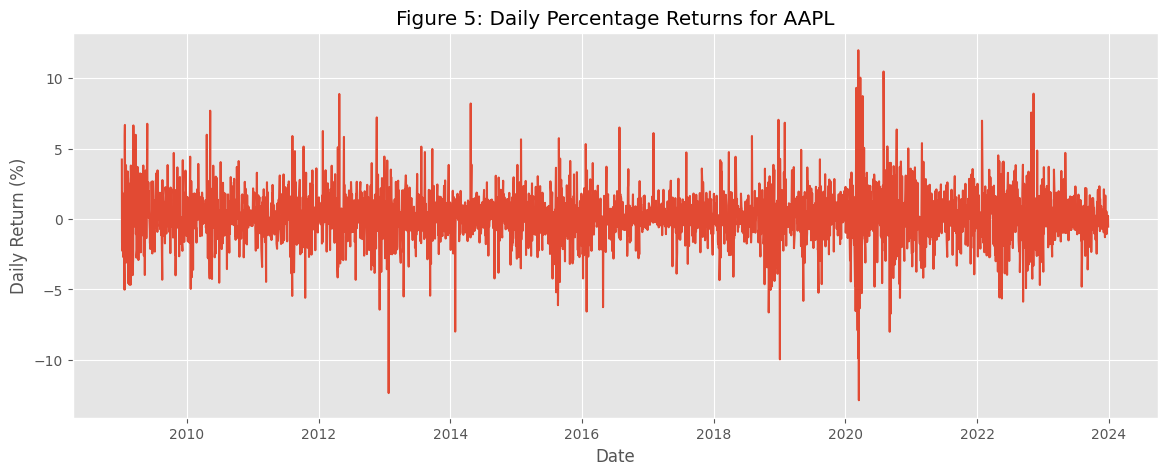

In [16]:
plt.figure(figsize=(14,5))

plt.plot(aapl_df["Date"], aapl_df["Daily_Return"])

plt.title("Figure 5: Daily Percentage Returns for AAPL")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.show()

### Interpretation of Figure 5

Figure 5 illustrates the day-to-day percentage movement in Apple’s stock price. Large spikes in returns represent periods of elevated volatility and may later correspond with major financial news events or sentiment changes.

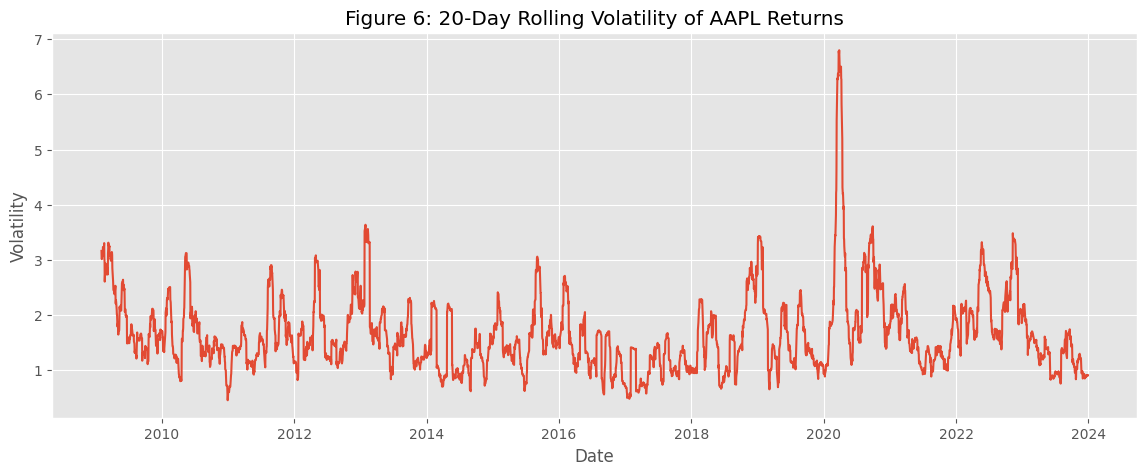

In [17]:
rolling_volatility = aapl_df["Daily_Return"].rolling(window=20).std()

plt.figure(figsize=(14,5))

plt.plot(aapl_df["Date"], rolling_volatility)

plt.title("Figure 6: 20-Day Rolling Volatility of AAPL Returns")
plt.xlabel("Date")
plt.ylabel("Volatility")

plt.show()

### Interpretation of Figure 6

Rolling volatility measures the variability of daily returns over time. Periods of higher volatility may indicate increased market uncertainty or stronger investor reactions to information entering the market.

# Preliminary Technical Analysis Findings

- TA-Lib was used to compute standardized SMA, EMA, RSI, and MACD indicators for reproducible financial analysis.

The quantitative analysis produced several important findings:

1. Apple’s stock price demonstrates clear periods of upward and downward trend movement.
2. SMA and EMA indicators reveal changes in short-term and medium-term momentum.
3. RSI analysis identifies periods approaching overbought and oversold conditions.
4. Daily return analysis highlights episodes of elevated volatility that may later be linked to financial news sentiment.
5. Technical indicators provide a quantitative foundation that will later be integrated with sentiment analysis results.

These findings establish the initial market-behavior framework required for the final correlation analysis stage.

## PyNance-Style Financial Metrics

To complement TA-Lib indicators, additional financial performance metrics were calculated, including cumulative return, rolling volatility, and drawdown. These metrics support risk and performance interpretation beyond trend and momentum indicators.

Additional performance-oriented metrics such as cumulative return and rolling volatility were incorporated to extend technical analysis toward broader financial risk evaluation.

In [18]:
# Select adjusted close when available, otherwise close
if "Adj Close" in aapl_df.columns:
    price_col = "Adj Close"
elif "Adj_Close" in aapl_df.columns:
    price_col = "Adj_Close"
else:
    price_col = "Close"

# Daily returns
aapl_df["Daily_Return"] = aapl_df[price_col].pct_change() * 100

# Cumulative return
aapl_df["Cumulative_Return"] = (1 + aapl_df["Daily_Return"] / 100).cumprod() - 1

# Rolling volatility
aapl_df["Rolling_Volatility_20"] = aapl_df["Daily_Return"].rolling(window=20).std()

# Drawdown
aapl_df["Cumulative_Max"] = aapl_df[price_col].cummax()
aapl_df["Drawdown"] = (aapl_df[price_col] - aapl_df["Cumulative_Max"]) / aapl_df["Cumulative_Max"]

aapl_df[["Date", price_col, "Daily_Return", "Cumulative_Return", "Rolling_Volatility_20", "Drawdown"]].head()

,Date,Close,Daily_Return,Cumulative_Return,Rolling_Volatility_20,Drawdown
0,2009-01-02,2.721686,NaN,NaN,NaN,0.000000
1,2009-01-05,2.836553,4.220416,0.042204,NaN,0.000000
2,2009-01-06,2.789767,-1.649399,0.025014,NaN,-0.016494
3,2009-01-07,2.729484,-2.160860,0.002865,NaN,-0.037746
4,2009-01-08,2.780169,1.856959,0.021488,NaN,-0.019878


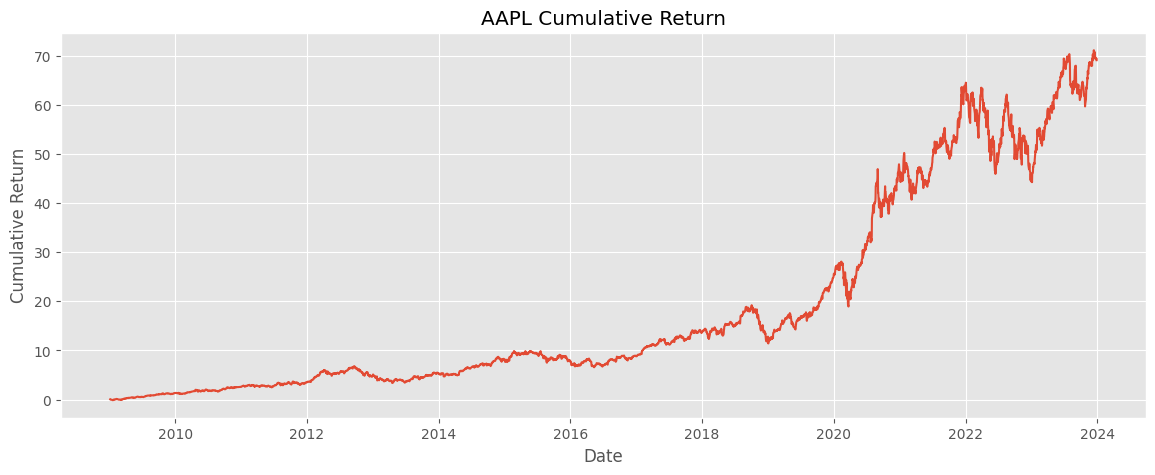

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(aapl_df["Date"], aapl_df["Cumulative_Return"])

plt.title("AAPL Cumulative Return")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")

plt.show()

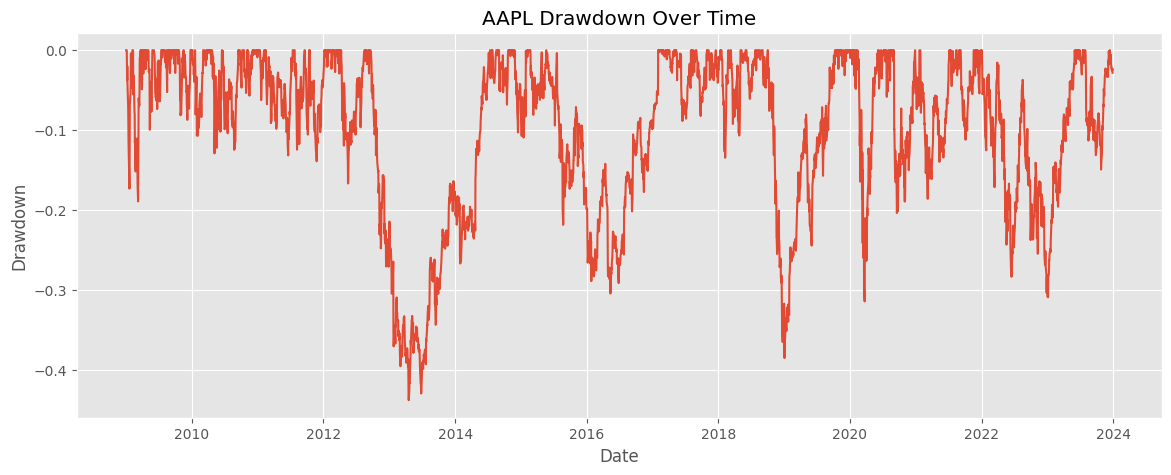

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(aapl_df["Date"], aapl_df["Drawdown"])

plt.title("AAPL Drawdown Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.show()

### Interpretation

Cumulative return shows the overall performance path of the stock, while rolling volatility and drawdown provide risk-oriented context. These metrics complement TA-Lib indicators by connecting technical signals with investment performance and downside risk.

# Relevance to the Business Objective

This technical analysis supports Nova Financial Solutions’ objective of improving predictive analytics through integrated market intelligence. Technical indicators help quantify market behavior and momentum, while later sentiment analysis will determine whether financial news tone contains predictive information about future stock movement.

# Next Steps

The next phase of the project will:

- Compute additional indicators such as MACD.
- Align financial news dates with stock trading dates.
- Apply sentiment scoring using NLP techniques such as VADER or TextBlob.
- Aggregate daily sentiment scores by stock.
- Calculate Pearson correlation between sentiment and daily returns.
- Visualize the relationship between sentiment and market movement using scatter plots and comparative analysis.

This integration phase will determine whether financial news sentiment can provide predictive insight into stock price behavior.

The computed technical indicators and return metrics will be integrated with financial news sentiment scores in the next phase to evaluate potential predictive relationships between market sentiment and stock performance.

In [21]:
print("Technical indicator analysis completed successfully.")
print(f"Final dataset shape: {aapl_df.shape}")

aapl_df.head()

Technical indicator analysis completed successfully.
Final dataset shape: (3774, 19)


,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACD_signal,MACD_hist,Daily_Return,Cumulative_Return,Rolling_Volatility_20,Cumulative_Max,Drawdown
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.721686,0.000000
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.220416,0.042204,NaN,2.836553,0.000000
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.649399,0.025014,NaN,2.836553,-0.016494
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.160860,0.002865,NaN,2.836553,-0.037746
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.856959,0.021488,NaN,2.836553,-0.019878
